# 45도 단면 다중모드 파이버의 광전파

## 정방향과 역방향 코드의 실제 알고리즘과 수식

입력 벡터장부터 경계면, 파이버 내부, 출사면과 카메라 기록까지 설명한다. 기존에 확인한 코드 스냅샷에 근거한 구현 분석이며, 새로운 전체 광선 시뮬레이션의 실행 결과는 아니다.

**분석 대상**

- [angled45/mmf_angled45_main.py](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py)
- [angled45/mmf_angled45_reverse_main.py](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py)

**분석 기준 커밋**: [c6a399ce07fd095daee3bedfee1fb04ccac07f4d](https://github.com/z-labo/Raytracing/commit/c6a399ce07fd095daee3bedfee1fb04ccac07f4d)

**형식 변경일**: 2026-09-17

## 읽는 방법

각 절의 출처 링크는 분석 커밋의 해당 코드 행으로 연결된다. 설명과 수식은 Markdown 셀에 들어 있으며, 표시 수식은 모두 `$$`로 둘러싼 LaTeX이다. 이 노트북은 설명 문서이므로 실행할 코드 셀은 없다. 그림은 파일 안에 포함되어 별도 이미지 파일이 필요하지 않다. 비공개 저장소의 링크를 열려면 GitHub 로그인과 저장소 접근 권한이 필요하다.

## 목차

- [1 구현의 핵심과 실행 순서](#section-01)
- [2 광학계의 수치와 좌표](#section-02)
- [3 정방향 입력 벡터장의 실제 생성](#section-03)
- [4 광선의 교차점과 경계 매질](#section-04)
- [5 입구와 경계면의 Snell 및 Fresnel 처리](#section-05)
- [6 파이버 내부의 위상과 편광 전파](#section-06)
- [7 확률적 분기와 코히런트 Monte Carlo](#section-07)
- [8 45도 끝면에서 측면으로 나오는 경로](#section-08)
- [9 출사 광선을 측면 기준면으로 모으는 방법](#section-09)
- [10 유한 픽셀의 복소장과 강도 합산](#section-10)
- [11 기준면에서 카메라까지의 벡터 각 스펙트럼법](#section-11)
- [12 역방향 점광원의 벡터장과 면적 표본화](#section-12)
- [13 역방향 경계 통과와 출구 기록](#section-13)
- [14 선택 가능한 analytic 입력 분기](#section-14)
- [15 정방향과 역방향의 대응과 한계](#section-15)
- [16 결과를 해석할 때 확인할 사항](#section-16)

## 기호와 단위

| 기호 | 의미 |
| --- | --- |
| E, H | 복소 전기장과 상대 단위 자기장 |
| k̂, k₀, λ₀ | 단위 진행 방향, 진공 파수, 진공 파장 |
| L, a, Δ | 파이버 축상 길이, 코어 반경, 격자 간격 |
| W, N₀, * | 중요도 가중치, 총 발사 수, 복소공액 |
| f / r | 정방향 / 역방향 좌표 |
| u, v, w | 측면의 오른손 국소 기저 |

<a id="section-01"></a>

## 1 구현의 핵심과 실행 순서

**근거**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136)

이 두 프로그램은 동일한 45도 단면 광섬유의 양쪽에서 전파를 계산한다. 현재 기본 실행은 reverse를 먼저 수행하여 평평한 단면 바로 밖의 방향별 복소 전기장을 저장하고, main이 그 채널을 위상공액하여 반대쪽으로 재입사시키는 순서다. main 안의 define_input_vector_field는 기본 실행에서 입력장을 만드는 함수가 아니다. INPUT_MODE를 analytic으로 바꿀 때만 그 함수가 사용된다.

실제 계산은 세 부분의 결합이다. 파이버 안팎의 경계 사이에서는 기하광학 광선의 직선 경로를 계산하고, 각 경로에 3성분 복소 전기장·Fresnel 진폭·광로 위상을 붙인다. 출사 광선은 유한 픽셀에 코히런트하게 합산한다. 정방향에서는 이 기준면장을 FFT 기반 벡터 각 스펙트럼법으로 측면 카메라까지 전파한다. 파이버 내부를 격자로 나누어 Maxwell 방정식을 직접 푸는 방식이나 유도모드 고유치 전개는 이 기본 호출 경로에 없다.

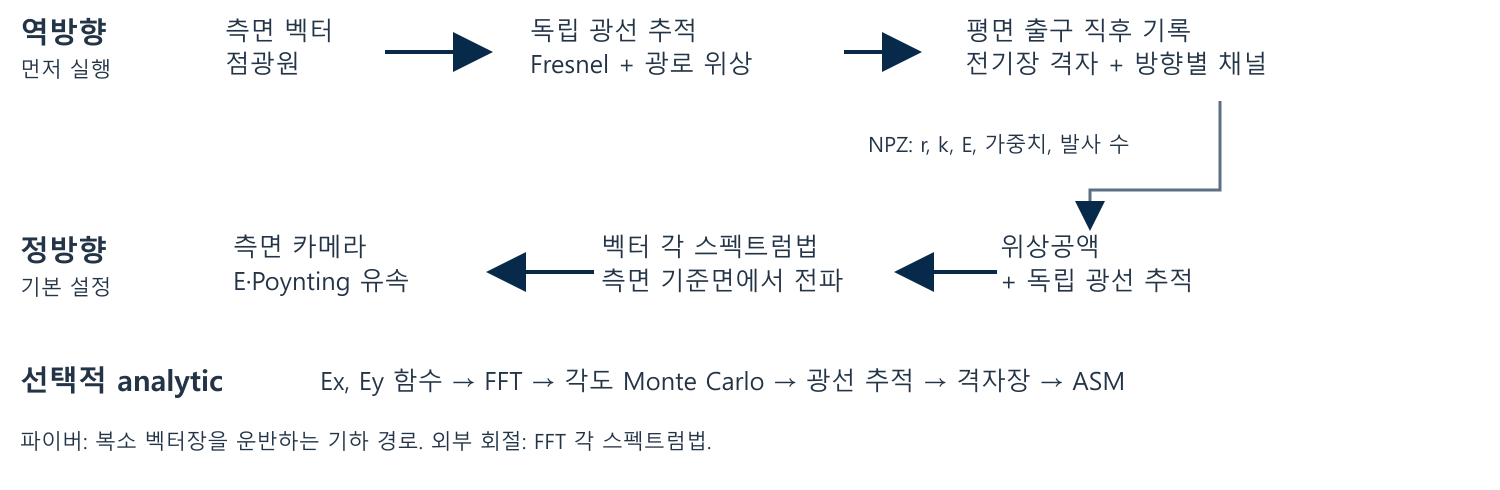

*그림 1. 실제 실행 순서. 기본 설정은 역방향 계산으로 채널을 저장한 다음 정방향에서 위상공액 재입사한다.*

이 문서의 식은 아래에 연결한 실제 코드의 연산을 수학적으로 정리한 것이다. 기본값에서 유도한 수치는 계산값이며, 새로운 광선 시뮬레이션의 측정 결과를 뜻하지 않는다. 각 절의 출처는 분석 커밋에 고정된 GitHub 행 링크다.

<a id="section-02"></a>

## 2 광학계의 수치와 좌표

**근거**: [S02 · L6–L33](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_parameters.py#L6-L33) · [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S06 · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136)

| 항목 | 현재 값 |
| --- | --- |
| 진공 파장 | 0.633 μm = 0.000633 mm |
| 굴절률 | core 1.4469   clad 1.3001   outside 1.0 |
| 코어와 클래딩 반경 | 0.0525 mm / 0.0625 mm |
| 축상 단면 중심 | L = 3.6 mm |
| 단면 기울기와 방위각 | 45° / 0° |
| 정방향 목표점 | (−0.1625, 0, 3.6) mm |
| 측면 기준면 중심 | (−0.0625, 0, 3.6) mm |
| 기준면에서 카메라까지 | 0.1000 mm |
| 필드 격자 | 512 × 512; Δ = 0.15 / 512 mm = 0.29296875 μm |
| 역방향 발사 표본 | 262144; seed 12345 |
| 최대 상호작용 | 200; 최소 교차 거리 10 nm |

$$
z_f=L-\tan(\theta )(x\cos \phi +y\sin \phi ),\quad z_r=L-z_f
$$

정방향 평면 입구는 z_f=0이고 45도 끝면은 기본값에서 z_f=L−x이다. 역방향 좌표는 x,y를 유지하고 z_r=L−z_f로 바꾼다. 따라서 역방향 기울어진 면은 z_r=x, 평면 출구는 z_r=L, 점광원은 (−0.1625,0,0) mm가 된다. 이는 같은 물체의 좌표 표현을 바꾼 것이며, 파이버를 다른 형상으로 새로 만든다는 뜻이 아니다.

$$
e_w=(-1,0,0),\quad e_v=(0,0,1),\quad e_u=e_v\times e_w=(0,-1,0)
$$

측면장의 성분 순서는 전역 (x,y,z)가 아니라 오른손 국소 기저 (u,v,w)이다. 따라서 기본값에서는 (E_u,E_v,E_w)=(−E_y,E_z,−E_x)이다. u는 −y 방향이고 v는 z 오프셋이다. main의 옛 docstring에 있는 x=−0.2625 mm나 FACET_DISTANCE_MM=0.20을 현재 카메라 위치·거리로 사용하면 틀린다. 실제 위치는 FOCUS_X_MM, FOCUS_Y_MM와 focus_geometry가 결정한다.

<a id="section-03"></a>

## 3 정방향 입력 벡터장의 실제 생성

**근거**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S05 · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165) · [S23 · L44–L64](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L44-L64)

기본 main은 reverse_exit_field_angled45.npz의 channel_points, channel_directions, channel_electric, channel_weights와 총 발사 수를 읽는다. 이 정보는 픽셀의 진폭·위상만 가진 2차원 영상보다 많다. 같은 픽셀에 여러 방향의 광선이 들어와도 채널별 진행 방향과 3성분 복소 전기장을 따로 보존한다. 저장 버전 4와 angled45_ray_channels_v1, 물리 파라미터, 광원 위치, 격자, 편광 및 Monte Carlo 옵션을 검사한다.

$$
D=\mathrm{diag}(1,1,-1),\quad r_f=(x_r,y_r,L-z_r)
$$

$$
\hat{k}_f=-D\hat{k}_r,\quad E_f=D E_r^{*}
$$

복소공액은 위상의 부호를 반전시킨다. 여기에 좌표 반사 D를 함께 적용하므로 k_x,k_y는 반전되고 k_z는 유지되며, E_z는 공액 후 부호가 반전된다. 전기장 세 성분에 무조건 공액만 취하는 설명은 불완전하다. 변환된 채널을 동일한 격자로 다시 합산한 장과 D E_exit*의 상대 노름 오차 NRMS가 10⁻¹⁰ 이하인지 확인한다. 이 검사는 저장 데이터와 재생 입력의 일치 검사이며, 카메라 초점의 물리적 정확도를 보증하는 검사가 아니다.

이 분기에서는 입력 FFT를 통한 각도 재표본화나 입력 전력 재정규화를 하지 않는다. PhaseConjugateInput의 보간기는 메타데이터 검증 과정에서 만들어지지만, 실제 재입사에 평가되어 사용되지 않는다. 입력면보다 축방향으로 0.0001 mm 앞선 공기 쪽에서 추적을 시작하고, 그만큼의 전파 위상을 미리 빼서 z=0에서 원래 채널 위상이 복원되도록 한다.

$$
s=\frac{10\varepsilon }{k_{f,z}},\quad r_{start}=r_f-s\hat{k}_f,\quad E_{start}=E_f e^{-i k_0 n_{out}s}
$$

<a id="section-04"></a>

## 4 광선의 교차점과 경계 매질

**근거**: [S06 · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103) · [S11 · L1856–L1945](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1856-L1945) · [S12 · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123) · [S19 · L194–L314](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L194-L314)

광선의 다음 교차면은 비순차 추적으로 결정한다. 즉 면을 미리 정한 순서로 한 번씩 통과시키지 않고, 현재 위치·방향에서 가장 가까운 유효 교차점을 찾는다. 파이버의 코어 경계, 클래딩 외벽, 평면 입구와 기울어진 끝면에는 mmf_angled_geometry의 해석적 교차 함수를 설치한다. 따라서 현재 경로 계산에서 원통은 256각형 벽의 근사 법선으로 반사되는 것이 아니다. PyVista 메시와 해상도 값은 형상 구성·표시 및 일부 다른 면 처리에도 남아 있다.

$$
a t^2+b t+c=0,\quad a=d_x^2+d_y^2,\quad b=2(o_xd_x+o_yd_y),\quad c=o_x^2+o_y^2-R^2
$$

$$
q=-\frac{1}{2}[b+\mathrm{copysign}(\sqrt{b^2-4ac},b)],\quad t_1=\frac{q}{a},\quad t_2=\frac{c}{q}
$$

원통 교차는 위의 이차방정식을 풀고, 벽 근처의 상쇄오차를 줄이는 안정한 근 계산을 사용한다. 평면 교차는 t=(h−n·o)/(n·d)로 계산한다. 유효 반경, 입구와 기울어진 끝면 사이의 z 범위, 최소 교차 거리 ε=10⁻⁵ mm를 검사하고 가장 가까운 양의 교차점을 채택한다. 원통 법선은 반경 방향, 끝면 법선은 해석적으로 얻는다. 역방향도 먼저 정방향 표준 형상 좌표로 변환하여 같은 교차 함수를 사용하고 결과를 역변환한다.

q=0인 퇴화 경우에는 t=−b/(2a)를 사용한다. 매질은 현재 매질, 경계 이름, 교차점의 반경과 정방향의 z 범위를 이용해 판정한다. 내부 원통은 core↔clad, 외부 원통은 clad↔air, 코어 끝면은 core↔air를 연결한다. 역방향에는 같은 물리적 연결 규칙을 별도 resolver로 적용한다. 이것이 클래딩을 통과한 광선을 계속 코어 광선으로 잘못 취급하지 않게 하는 부분이다.

<a id="section-05"></a>

## 5 입구와 경계면의 Snell 및 Fresnel 처리

**근거**: [S05 · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165) · [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S09 · L745–L1099](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L745-L1099) · [S10 · L1173–L1240](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/KrakenOS/KrakenSys.py#L1173-L1240)

기본 정방향은 공기에서 실제 평면 입구를 추적한다. Kraken이 Snell 법칙에 따른 굴절 방향 또는 반사 방향을 계산하고, 공통 편광 재생 함수가 동일한 사건에 복소 Fresnel 진폭을 적용한다. 여기서 n₁은 입사 매질, n₂는 통과할 매질이며, 법선은 입사 방향과 내적이 양수가 되도록 정렬한다. k₀=2π/λ₀에서 λ₀는 mm로 변환한다.

$$
n_1\sin \theta _i=n_2\sin \theta _t,\quad c_t=\sqrt{1-(\frac{n_1}{n_2}\sin \theta _i)^2+0i}
$$

$$
r_s=\frac{n_1c_i-n_2c_t}{n_1c_i+n_2c_t},\quad r_p=\frac{n_2c_i-n_1c_t}{n_2c_i+n_1c_t}
$$

$$
t_s=\frac{2n_1c_i}{n_1c_i+n_2c_t},\quad t_p=\frac{2n_1c_i}{n_2c_i+n_1c_t}
$$

c_i=cosθ_i이다. 제곱근은 Im(c_t)≥0인 가지를 선택한다. 전반사에서는 c_t가 허수가 되어 r_s,r_p에 위상이 생긴다. 반사율이 1이라는 이유로 전기장을 그대로 두면 s와 p 사이의 위상차를 잃으므로, 이 코드는 전반사에서도 복소 반사계수를 곱한다. 진폭 투과계수 |t|²는 곧바로 전력 투과율이 아니며, 아래의 굴절률·각도 인자를 함께 사용한다.

$$
T_{s,p}=\frac{n_2\mathrm{Re}(c_t)}{n_1c_i}|t_{s,p}|^2
$$

국소 s축은 n×k를 정규화하여 만들고, p축은 k×s에서 만든다. 정상 입사로 외적이 퇴화하면 대체 횡방향 기저를 사용한다. 복소 전기장을 이 기저로 분해하여 계수를 곱한 뒤, 새로운 반사·굴절 방향의 기저를 통해 전역 xyz 성분으로 돌아온다. 따라서 고정된 전역 x,y 성분에 같은 스칼라 계수를 곱하는 모델이 아니다.

<a id="section-06"></a>

## 6 파이버 내부의 위상과 편광 전파

**근거**: [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S09 · L745–L1099](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L745-L1099)

$$
\mathrm{OPL}=\sum_j n_j\ell_j,\quad E\leftarrow E e^{i k_0 n_j\ell_j},\quad k_0=\frac{2\pi }{\lambda _0}
$$

RayState는 현재 위치, 단위 진행 방향, 3성분 복소 전기장, 현재 굴절률, 누적 광로 길이, 전파 위상, 반사 횟수와 표본 가중치를 저장한다. 두 교차점 사이의 유클리드 거리 ℓ_j에 해당 구간의 굴절률을 곱해 OPL을 누적하고 exp(i k₀n_jℓ_j)를 전기장에 곱한다. 광선 자체는 균질한 매질 안에서 직선으로 움직이고, 내부 전파를 z 스텝별 FFT나 유한차분으로 풀지 않는다.

$$
E_s=s\cdot E,\quad E_p=p\cdot E,\quad E_{refl}=r_sE_s s_r+r_pE_p p_r
$$

$$
E_{trans}=t_sE_s s_t+t_pE_p p_t,\quad E\leftarrow E-\hat{k}(\hat{k}\cdot E)
$$

각 경계 이후의 p축은 새로운 진행 방향으로 다시 계산한다. 이 기저 회전과 s,p의 서로 다른 복소 계수 때문에 공간적으로 변하는 편광과 전반사 지연 위상이 유지된다. 마지막 식의 횡파 보정은 수치적 종방향 잔차를 제거한다. 단, 전역 E_z가 항상 0이라는 뜻은 아니다. 비스듬한 광선은 k·E=0을 만족하면서도 E_z를 가질 수 있다.

trace_core_polarization은 Kraken의 기하 경로와 매질·법선 기록을 읽어 이 연산을 재생한다. 이는 역방향으로 빛을 돌리는 의미의 재생이 아니라, 이미 얻은 경로에 복소 벡터장을 부여하는 두 번째 계산 단계다. 영길이 구간, 검출점 불일치, 잘못된 매질 등의 진단을 수행하며, 기본 설정은 영길이 구간을 포함한 기록을 최종 코히런트 합산에서 제외한다.

<a id="section-07"></a>

## 7 확률적 분기와 코히런트 Monte Carlo

**근거**: [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S10 · L1173–L1240](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/KrakenOS/KrakenSys.py#L1173-L1240) · [S05 · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165) · [S14 · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41)

일반적인 비전반사 경계에서 Kraken은 한 광선을 반사·투과 두 광선으로 항상 복제하지 않는다. energy_probability=1일 때 무편광 평균 Fresnel 전력에 따른 확률로 한 분기를 선택한다. 편광별 실제 전기장 진폭은 별도의 Jones 계산에서 적용하므로, 분기 선택 확률과 전기장 계수를 구분해야 한다.

$$
P_R=\frac{|r_s|^2+|r_p|^2}{2},\quad P_T=1-P_R,\quad W\leftarrow \frac{W}{P_b}
$$

$$
\mathbb{E}[\frac{\mathbf{1}_b}{P_b}a_b]=a_b
$$

선택된 분기의 물리적 복소 진폭 a_b는 Fresnel 계수를 포함하고, sampling_weight에는 1/P_b를 별도로 누적한다. 복소장 평균을 구하는 중요도 표본화이므로 1/√P_b가 아니다. 전반사에서는 P_R=1이다. 분기 확률이 10⁻¹² 이하이면 안정한 보정을 만들 수 없다고 예외를 발생시킨다. 작은 확률의 경로는 큰 가중치를 만들어 분산을 키울 수 있다.

정방향 재입사에서는 역방향 파일의 가중치를 한 번 전달하고, 새 정방향 추적에서 발생한 분기의 보정은 독립적으로 누적한다. 정방향은 저장된 경로를 역순으로 강제하지 않고 새로 경로를 찾는다. 복소장 추정량의 분기 보정이 맞다는 사실만으로 그 제곱에서 구한 강도가 유한 표본에서 무편향이 되거나, 전체 광학 모델이 정확해지는 것은 아니다. 수렴성은 광선 수·시드·격자에 대해 별도로 확인해야 한다.

<a id="section-08"></a>

## 8 45도 끝면에서 측면으로 나오는 경로

**근거**: [S02 · L6–L33](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_parameters.py#L6-L33) · [S06 · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103) · [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S11 · L1856–L1945](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1856-L1945) · [S12 · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123)

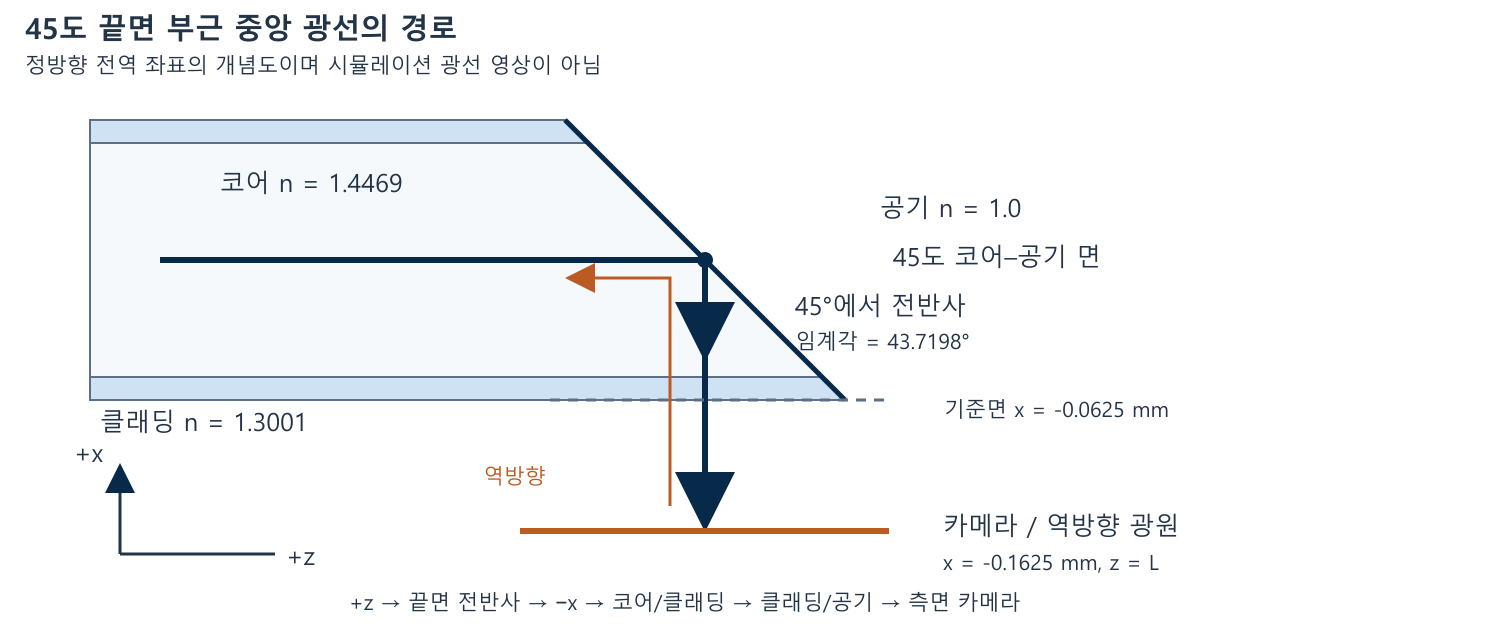

*그림 2. 45도 끝면 부근 중앙 광선의 개념 경로. 시뮬레이션으로 얻은 광선 영상은 아니다.*

기본값의 축방향 중앙 광선은 +z_f로 진행하여 법선 (1,0,1)/√2의 코어 끝면에 45도로 입사한다. core–air 임계각은 asin(1/1.4469)=43.7198도이므로 이 대표 경로는 전반사한다. 반사 방향은 −x가 되고, 이후 원통형 core–clad 경계와 clad–air 외벽을 통과하여 측면 카메라로 진행한다. 45도 끝면에서 즉시 공기로 투과하는 경로로 설명하면 이 주요 광경로를 놓친다.

$$
\hat{k}_{refl}=\hat{k}_{in}-2(\hat{k}_{in}\cdot \hat{n})\hat{n},\quad (0,0,1)\rightarrow (-1,0,0)
$$

모든 광선이 같은 각도로 입사하는 것은 아니다. 위치와 방향에 따라 45도 면에서 투과하거나 클래딩으로 누설되는 경로도 포함된다. 코어–클래딩 임계각은 63.9670도이며 NA=√(n_core²−n_clad²)=0.635027은 재료값에서 계산되는 값이다. 이 숫자만으로 현재 채널의 실제 도달률이나 초점 크기를 정할 수는 없다. 기본 재생은 저장된 유효 채널을 사용하고, 선택적 analytic 분기도 AS_GUIDED_ONLY=False이므로 NA 바깥 성분을 사전에 모두 제거하지 않는다.

<a id="section-09"></a>

## 9 출사 광선을 측면 기준면으로 모으는 방법

**근거**: [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S12 · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123) · [S13 · L2584–L2739](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2584-L2739) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233)

기본 KRAKEN_CAPTURE_GAP_MM=None은 focus_geometry가 계산한 0.1 mm로 대체된다. 기하 추적의 측면 capture disk는 실제 카메라 중심과 같은 위치에 놓이고 반경은 0.30 mm이다. 그러나 그 검출점의 광선 수를 최종 카메라 영상으로 바로 쓰지 않는다. output_detector_side에 도달한 유효 기록을 선택하여 광선 방향을 따라 고정 기준면 x=−0.0625 mm로 되돌린 뒤 파동 전파를 계산한다.

$$
s=-\frac{(r_{det}-c_{ref})\cdot e_w}{\hat{k}\cdot e_w},\quad r_{ref}=r_{det}+s\hat{k}
$$

$$
E_{ref}=E_{det}e^{i k_0 n_{out}s},\quad (u,v)=((r_{ref}-c_{ref})\cdot e_u,(r_{ref}-c_{ref})\cdot e_v)
$$

카메라가 기준면보다 진행 방향 앞쪽에 있으면 s는 음수다. 그 구간의 위상을 빼므로 기준면 이후 거리를 두 번 더하지 않는다. 전기장과 진행 방향도 (u,v,w) 국소 좌표로 회전한다. 검사 조건은 검출점과 상태 위치의 일치, 외부 굴절률, k·e_w>0, 기준면 반폭 0.075 mm 이내, 영길이 구간 배제 등이다. 검출면 도달 여부와 최종 필드 합산에 채택되는 여부는 다를 수 있다.

기본 phase_conjugate 결과의 E_reference와 E_camera는 이 측면장이다. z방향으로 누설된 광선의 기록은 남지만 별도의 축방향 이미지를 계산하지 않아 E_camera_z 등은 None이다. camera_z_mm=L은 측면 카메라 중심의 전역 z좌표이며, 파동이 +z축으로 진행한다는 뜻이 아니다.

<a id="section-10"></a>

## 10 유한 픽셀의 복소장과 강도 합산

**근거**: [S14 · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41) · [S21 · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673) · [S22 · L2477–L2582](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2477-L2582)

정방향 측면 기준면과 역방향 평면 출구는 accumulate_field를 공유한다. 좌표를 가장 가까운 격자 노드의 셀로 배정하고, 광선 교차점에서 셀 중심까지의 횡방향 위상을 보정한다. 면적 적분을 나타내는 복소장 기여를 총 발사 수 N₀와 셀 면적 Δ²로 나누어 전기장을 합한다. 한 픽셀에 들어온 광선 개수만으로 나누는 평균도 아니고, 각 광선 강도를 먼저 합하는 비코히런트 계산도 아니다.

$$
\Phi _{jp}=k_0n_{out}\hat{k}_{j,\perp }\cdot (\rho _p-\rho _j)
$$

$$
E_p=\frac{1}{N_0\Delta ^2}\sum_{j\in C_p}W_j E_j e^{i\Phi _{jp}}
$$

$$
H_p=\frac{1}{N_0\Delta ^2}\sum_{j\in C_p}n_{out}(\hat{k}_j\times E_j)W_j e^{i\Phi _{jp}}
$$

$$
I_p=\frac{1}{2}\mathrm{Re}(E_p\times H_p^{*})\cdot e_w
$$

N₀는 역방향의 원래 총 발사 수 262144이다. 기본 정방향 재생에서도 보존되어 다시 쏘는 채널 개수로 바꾸지 않고, 이 역방향 원래 발사 수를 그대로 분모에 사용한다. analytic 분기는 해당 실행의 위치 수와 각 표본 수의 곱을 사용한다.

자기장은 코드의 상대 단위 H=n(k̂×E)로 정의된다. 정방향 측면 계산에서는 e_w가 국소 세 번째 축이며, 역방향 평면에서는 +z_r이다. 서로 다른 광선의 위상차가 E와 H의 합 안에서 간섭을 만들기 때문에 이 강도는 일반적으로 |E|²와 같지 않다. 임피던스의 SI 상수, 검출기 감도, 노출 시간, 광자수 변환을 적용한 W/m² 또는 카메라 count는 아니다.

이 방식은 유한 셀 위의 광선 기반 장 추정이다. 셀 안에서 국소 평면파 위상을 사용하고, 각 광선의 방향 정보를 격자 합으로 압축한다. 광선 수가 적거나 분포가 불균일하면 비어 있는 셀과 큰 통계 변동이 생길 수 있다. 코드의 hit_count와 active_pixels는 이 샘플링 상태를 확인하기 위한 진단이다.

<a id="section-11"></a>

## 11 기준면에서 카메라까지의 벡터 각 스펙트럼법

**근거**: [S15 · L2741–L2821](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2741-L2821) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S28 · L237–L288](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L237-L288) · [S29 · L2824–L2885](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2824-L2885)

propagate_vector_angular_spectrum은 512×512 기준면장을 2048×2048로 zero padding한다. 픽셀 간격은 그대로 유지되므로 padding은 시야와 주파수 표본 간격을 바꾸지만 원래 필드의 공간 해상도를 네 배 높이지 않는다. 세 성분에 centered FFT를 적용하고 국소 횡파수 k_u,k_v에 대해 전파 가능한 성분만 남긴다.

$$
k_w=\sqrt{(n_{out}k_0)^2-k_u^2-k_v^2},\quad k_u^2+k_v^2\leq (n_{out}k_0)^2
$$

$$
A_w=-\frac{k_uA_u+k_vA_v}{k_w},\quad A(d)=A(0)e^{i k_w d}
$$

코드는 A_u,A_v를 유지하고 횡파 조건으로 A_w를 다시 만든다. 입력의 세 번째 성분 FFT는 덮어쓴다. 주석의 일반적인 직교 투영이라는 표현보다 이 실제 연산을 기준으로 이해해야 한다. k_w가 10⁻¹⁰ n_out k₀ 이하인 거의 접선 방향 성분과 에바네슨트 성분은 버린다. 따라서 역방향 영거리 기록면에서 방향별 채널을 그대로 보존하는 처리와 이 FFT 재구성은 서로 다르다.

$$
E_{cam}=\mathcal{F}^{-1}[A(d)],\quad H_{cam}=\mathcal{F}^{-1}[n_{out}(\hat{k}\times A(d))]
$$

전파 거리 d=0.1 mm를 적용한 뒤 E와 H를 각각 역FFT하고 I=½Re(E×H*)_w를 계산한다. 마지막으로 카메라 반폭 0.20 mm로 자른다. 이 식은 k_w를 포물선으로 근사하는 Fresnel 근축식이 아니라 제곱근 분산식을 사용하는 ASM이다. 다만 단방향 전파 가능한 스펙트럼, 유한 창, 이산 격자라는 제한은 남는다. 구현은 이 함수에서 NumPy FFT를 사용한다. USE_GPU_NUMERICS=True라는 설정만으로 이 카메라 전파가 GPU에서 실행된다고 볼 수 없다.

저장되는 forward_camera_angled45.npz에는 국소 좌표계의 복소 카메라장, 강도, 좌표, 기준면장, 기저 및 목표점이 들어간다. 그림 표시에서는 최대 강도로 나누지만 원시 저장 강도를 그 정규화 영상과 혼동해서는 안 된다. 피크 좌표와 해당 행·열의 반치폭 FWHM은 강도 배열에서 계산하며, 다중 피크나 스펙클을 자동으로 이상적 초점으로 판정하지 않는다.

<a id="section-12"></a>

## 12 역방향 점광원의 벡터장과 면적 표본화

**근거**: [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136) · [S18 · L317–L367](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L317-L367)

역방향은 카메라의 기록 이미지를 읽어 역FFT하는 프로그램이 아니다. 정방향 목표점에 해당하는 위치 (−0.1625,0,0) mm에 수학적 점광원을 놓고, 기울어진 코어 면 위의 표적점을 뽑아 초기 광선 방향을 만든다. 반경은 a√U, 방위각은 2πV로 뽑으므로 xy 투영 원판에 균일하다. 평면의 기울기는 일정하므로 실제 기울어진 면에서도 면적 밀도가 일정하며, 면적은 πa²/cosθ이다.

$$
\rho =a\sqrt{U},\quad \psi =2\pi V,\quad x=\rho \cos \psi ,\quad y=\rho \sin \psi
$$

$$
z_r=\tan \theta (x\cos \phi +y\sin \phi ),\quad \hat{k}=\frac{r_{target}-r_{src}}{R}
$$

여기서 U,V는 [0,1)의 균일 난수이고 R은 광원에서 샘플 표적점까지의 직선 거리다. 이 표적점은 발사 방향을 정의할 뿐, 실제 첫 입사점이나 최종 45도 면 교차점을 강제하지 않는다. 광선은 그 전에 클래딩 외벽에서 굴절할 수 있기 때문이다. 전체 공간에 균일한 입체각으로 복사하는 모든 점광원 방향을 계산하는 설정도 아니다.

$$
E_0=J_u e_u+J_v e_v,\quad E_{launch}=\frac{\sqrt{P}A_{facet}}{R}[E_0-\hat{k}(\hat{k}\cdot E_0)]
$$

$$
A_{facet}=\frac{\pi a^2}{\cos \theta },\quad J=(1,0),\quad e_u=(0,1,0),\quad e_v=(0,0,1)
$$

P는 SOURCE_POWER=1.0의 상대 광원 스케일이다. 이 값만으로 절대 광출력의 와트 값을 지정한 것은 아니다.

기본 Jones 벡터는 광원 기저의 u 선편광이며 현재 기저에서는 +y이다. 각 광선 방향에 직교하도록 투영하되 다시 단위 진폭으로 만들지 않으므로 방향에 따른 진폭 변화가 남는다. 1/R은 코드의 구면파 진폭 모형이고, A_facet은 면적 적분 가중치다. 1/N은 여기서 곱하지 않고 나중의 픽셀 합산에서 한 번 적용한다. 초기식에는 exp(i kR)을 넣지 않는다. 광원부터 각 실제 경계까지의 위상은 공통 OPL 계산이 이미 누적하기 때문이다.

<a id="section-13"></a>

## 13 역방향 경계 통과와 출구 기록

**근거**: [S19 · L194–L314](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L194-L314) · [S20 · L369–L482](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L369-L482) · [S21 · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673) · [S22 · L2477–L2582](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2477-L2582) · [S23 · L44–L64](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L44-L64) · [S31 · L195–L215](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L195-L215)

대표적인 중앙 경로는 측면 공기→클래딩 외벽→클래딩→코어 경계→45도 core–air 면의 반사→+z_r 방향 코어 전파→평평한 core–air 출구이다. 역방향 기울어진 법선은 정방향 법선의 z성분을 반전시킨 것이다. 각 실제 경계에서는 정방향과 같은 Snell 방향 계산, s/p Fresnel 변환, 전반사 위상, 구간 OPL, 확률 분기 보정을 사용한다. 광원 위치만 반대로 놓고 모든 광선을 같은 경로로 통과시키는 단순한 연산은 아니다.

역방향 출구 기록은 z_r=L에서 공기로 나온 직후의 장을 의미한다. 수치 추적을 위해 그보다 약간 앞에 있는 보조 검출면을 두지만, 최종 채널은 그 여분의 공기 구간을 광선별로 역전파해 출구면으로 옮긴다. 따라서 EXIT_CAMERA_DISTANCE_MM=0과 모순되지 않는다. 재구성은 유효 출사 채널을 collect_reference_channels로 수집한 뒤 accumulate_field로 합산하며, 출구에 추가 자유공간 ASM을 적용하지 않는다.

역방향 최종 진행 방향에는 Kraken의 LMN 부호보다 실제 마지막 XYZ 구간 방향을 우선한다. 최종 E에서 남은 종방향 성분을 제거한 후 저장한다. 반환 E_exit는 (3,Ny,Nx), 정방향 카메라 E는 (Ny,Nx,3)이며 전기장 성분의 좌표계도 다르다. reverse_main의 amplitude_exit는 √Σ|E_c|²이고 intensity_exit는 Poynting flux이므로 두 영상을 같은 강도로 취급하면 안 된다.

NPZ에는 E_exit, x/y 좌표, 광원 위치, 좌표 변환 문자열, 물리 파라미터, 방향별 위치·전기장·방향·가중치·총 발사 수를 저장한다. intensity_exit는 반환 결과에 있으나 저장 함수의 NPZ 항목에는 직접 포함되지 않는다. main은 이 파일이 없거나 파라미터·격자가 다르면 재생을 중단한다.

<a id="section-14"></a>

## 14 선택 가능한 analytic 입력 분기

**근거**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S24 · L79–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L79-L136) · [S25 · L1133–L1280](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1133-L1280) · [S26 · L1281–L1403](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1281-L1403) · [S27 · L3067–L3235](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L3067-L3235)

INPUT_MODE=analytic으로 바꾸면 INPUT_FIELD_FUNCTION의 Ex,Ey를 격자로 평가한다. 현재 함수는 waist w₀=0.020 mm의 Gaussian 진폭에 exp(i2 atan2(y,x))를 곱한 x 선편광장이다. 라벨이 Gaussian input beam이라도 위상은 평탄하지 않고 전하 2의 와류 위상이다. 다만 진폭에 r² 인자를 넣은 표준 Laguerre–Gaussian 모드 전체를 구현한 것은 아니다. 코어 반경 밖을 마스크하고, 아래 식의 종방향 성분까지 포함한 순방향 Poynting 적분 P가 1이 되도록 전기장 전체를 1/√P배 한다. D는 FFT 창의 한 변 0.15 mm다.

$$
E_x=e^{-(r/w_0)^2}e^{2i\mathrm{atan2}(y,x)},\quad E_y=0
$$

$$
A_{x,y}=\Delta ^2\mathcal{F}[E_{x,y}],\quad A_z=-\frac{k_xA_x+k_yA_y}{k_{z,out}}
$$

$$
P=\frac{1}{D^2}\sum_{prop}\frac{n_{out}k_{z,out}}{2k_{out}}(|A_x|^2+|A_y|^2+|A_z|^2)
$$

2차원 FFT로 외부 angular spectrum을 만들고 전파 불가능한 성분을 제거한다. 최대 벡터 스펙트럼 진폭의 10⁻³를 cutoff로 사용한다. 각 성분의 접선 파수 k_x,k_y를 보존하여 코어의 k_z와 Snell 굴절 방향을 구하고, 평면 입구의 s/p Fresnel 투과계수를 미리 적용한다. 따라서 analytic은 코어 쪽 경계에서 출발하는 반면, 기본 phase_conjugate는 공기 쪽에서 실제 입구의 확률 분기까지 추적한다.

$$
p_m=\frac{\|A_m\|}{\sum_l\|A_l\|},\quad B_m=\frac{A_{core,m}}{p_mD^2}
$$

각 성분은 외부 벡터 진폭에 비례하는 확률 p_m으로 추출하고, 누적분포의 층화 표본화 u_m=(m+U_m)/M을 사용한다. 같은 bin이 여러 번 뽑혀도 그대로 별도 표본으로 유지한다. A_core,m은 입구 투과 후의 벡터 스펙트럼이며 코드 변수 q는 이 p_m이다. 소스 위치는 코어 원판의 균일 면적 샘플이다. 광선 초기 기여는 πa² B_m exp(i(k_xx+k_yy))로 주어진다. 현재 설정에서는 256개 위치마다 1024개 각 표본을 추적하여 262144개를 발사한다.

이후 내부 추적과 장 합산은 공통 함수를 사용한다. 다만 analytic의 일반 utility.run_simulation은 z카메라와 측면 카메라를 모두 구성하고 E_camera 기본 별칭은 z카메라를 가리킨다. 기본 위상공액 분기의 E_camera가 측면 카메라를 뜻하는 것과 구별해야 한다.

<a id="section-15"></a>

## 15 정방향과 역방향의 대응과 한계

**근거**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S14 · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41) · [S15 · L2741–L2821](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2741-L2821) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S18 · L317–L367](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L317-L367) · [S21 · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673)

| 비교 | 정방향 기본 | 역방향 |
| --- | --- | --- |
| 입력 | 저장 채널의 위상공액 | 측면 벡터 점광원 |
| 첫 경계 | 평면 air→core | 대표 경로 air→clad 외벽 |
| 45도 면 | 측면으로 돌리는 반사 | 축으로 돌리는 반사 |
| 파이버 내부 | 기하 경로와 복소 Jones 전파 | 동일한 국소 법칙 |
| 기록면 | 측면 기준면 후 0.1 mm ASM | 평면 출구 바로 밖 |
| 필드 좌표 | (Ny, Nx, 3), 국소 u, v, w | (3, Ny, Nx), 전역 x, y, z_r |
| 저장 | forward_camera_angled45.npz | reverse_exit_field_angled45.npz |

이 구현을 동일 광학계의 반대 방향 전파라고 설명하는 것은 타당하다. 그러나 전체 연산이 서로의 정확한 역행렬이라는 뜻은 아니다. 유한한 launch 영역과 검출 시야, 반사·투과로 빠져나가는 경로, 유효 기록 필터, 확률적 표본화, 셀 합산, ASM의 스펙트럼 절단이 있다. 한쪽 출구에서 수집한 채널만 위상공액해 재입사하므로 모든 외부 방사 채널을 동시에 시간 반전하는 계산이 아니다.

파이버 내부의 전기장 진폭은 Fresnel 계수와 시작 가중치로 운반되고, 각 구간은 위상만 갱신한다. 이 기본 복소장 계산에는 광선관 단면적의 Jacobian에 따른 진폭 갱신, 초점 통과의 별도 Maslov 위상, 경계의 에바네슨트 장 분포, 모드 고유치 해석, 거칠기·비선형 효과가 없다. 재료 흡수에 따른 진폭 감쇠도 이 복소장 재생에는 적용하지 않는다. 검출면에서 광선을 정지시키는 ABSORB 처리와는 구별해야 한다. 따라서 전반사 편광 위상을 포함한 벡터 기하광학과 외부 회절 계산을 결합한 근사라고 규정하는 것이 정확하다.

<a id="section-16"></a>

## 16 결과를 해석할 때 확인할 사항

**근거**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136) · [S28 · L237–L288](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L237-L288) · [S29 · L2824–L2885](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2824-L2885) · [S30 · L1–L10](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/_bootstrap.py#L1-L10)

동일 소스 스냅샷으로 실행할 때 순서는 angled45/mmf_angled45_reverse_main.py --no-plots 다음 angled45/mmf_angled45_main.py --no-plots이다. _bootstrap은 해당 폴더를 import 경로 앞에 두어 루트의 동명 모듈과 섞이지 않게 한다. 물리 파라미터, 목표점 또는 격자를 바꾸면 reverse 파일을 다시 만들어야 한다. 이 문서는 실행 절차와 구현을 설명하며, 전체 기본 광선 수로 재실행하여 초점 성능을 측정한 보고서는 아니다.

| 확인 대상 | 해석 |
| --- | --- |
| source_reconstruction_nrms | 저장 채널과 입력 격자장의 일치 |
| `n_field_hits`와 `skipped_*` | 기하 도달과 필드 채택의 구분 |
| `peak_global_mm`와 `target_error_um` | 국소 피크를 전역 좌표로 환산한 위치 오차 |
| FWHM | 피크 행과 열의 반치폭 |
| 강도 정규화 | 표시 영상과 저장 원시 배열을 구분 |
| 샘플 수와 격자 | 광선 수 증가와 격자 변경을 분리해 수렴 확인 |

소스 주석보다 실행식을 우선해야 하는 지점은 명확하다. 현재 입력은 위상공액 채널, 카메라 x좌표는 −0.1625 mm, 기준면 이후 거리는 0.1 mm, 출사 후 파동 전파축은 측면 w축이다. 또한 카메라 FFT는 NumPy이며, 횡파 보정은 두 횡성분을 보존하고 종성분을 다시 만드는 연산이다. 이 차이를 반영해야 실제 사용된 방법을 재현 가능한 설명으로 만들 수 있다.

## 출처 색인

아래 링크는 모두 동일한 분석 커밋에 고정되어 있다. 이후 master가 변경되어도 인용한 코드 행은 유지된다.

**S01 — 정방향 실행 분기**  
[angled45/mmf_angled45_main.py · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248)

**S02 — 공통 물리 파라미터**  
[angled45/mmf_parameters.py · L6–L33](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_parameters.py#L6-L33)

**S03 — 목표점과 카메라 좌표**  
[angled45/mmf_focus.py · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28)

**S04 — 방향 채널 검증과 위상공액**  
[angled45/mmf_phase_channels.py · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93)

**S05 — 공기 중 재입사와 독립 추적**  
[angled45/mmf_phase_channels.py · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165)

**S06 — 해석적 교차점과 법선**  
[angled45/mmf_angled_geometry.py · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103)

**S07 — 국소 기저와 Fresnel 계수**  
[angled45/mmf_vector_utility.py · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491)

**S08 — 광로 위상과 벡터장 갱신**  
[angled45/mmf_vector_utility.py · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728)

**S09 — 경계 사건별 편광 재생**  
[angled45/mmf_vector_utility.py · L745–L1099](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L745-L1099)

**S10 — Kraken 확률적 분기**  
[KrakenOS/KrakenSys.py · L1173–L1240](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/KrakenOS/KrakenSys.py#L1173-L1240)

**S11 — 경계 양쪽 매질 결정**  
[angled45/mmf_vector_utility.py · L1856–L1945](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1856-L1945)

**S12 — 광학계와 검출면 구성**  
[angled45/mmf_vector_utility.py · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123)

**S13 — 측면 기준면으로 되돌리기**  
[angled45/mmf_vector_utility.py · L2584–L2739](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2584-L2739)

**S14 — 유한 셀의 복소장 합산**  
[angled45/mmf_field.py · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41)

**S15 — 벡터 각 스펙트럼 전파**  
[angled45/mmf_vector_utility.py · L2741–L2821](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2741-L2821)

**S16 — 측면 카메라 출력과 저장**  
[angled45/mmf_phase_channels.py · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233)

**S17 — 역방향 소스와 영거리 기록면**  
[angled45/mmf_angled45_reverse_main.py · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136)

**S18 — 점광원 샘플과 초기 전기장**  
[angled45/mmf_vector_reverse_utility.py · L317–L367](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L317-L367)

**S19 — 역방향 매질과 광학계**  
[angled45/mmf_vector_reverse_utility.py · L194–L314](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L194-L314)

**S20 — 역방향 경로와 편광**  
[angled45/mmf_vector_reverse_utility.py · L369–L482](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L369-L482)

**S21 — 역방향 출사장 재구성**  
[angled45/mmf_vector_reverse_utility.py · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673)

**S22 — 출사 채널 수집과 평면장**  
[angled45/mmf_vector_utility.py · L2477–L2582](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2477-L2582)

**S23 — 역방향 NPZ 저장**  
[angled45/mmf_field.py · L44–L64](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L44-L64)

**S24 — 선택적 해석 입력과 샘플 수**  
[angled45/mmf_angled45_main.py · L79–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L79-L136)

**S25 — 입력장 FFT와 종방향 성분**  
[angled45/mmf_vector_utility.py · L1133–L1280](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1133-L1280)

**S26 — 각 성분과 위치의 중요도 표본화**  
[angled45/mmf_vector_utility.py · L1281–L1403](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1281-L1403)

**S27 — analytic 전체 실행 경로**  
[angled45/mmf_vector_utility.py · L3067–L3235](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L3067-L3235)

**S28 — 표시 정규화와 그림 저장**  
[angled45/mmf_phase_channels.py · L237–L288](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L237-L288)

**S29 — 피크와 FWHM 계산**  
[angled45/mmf_vector_utility.py · L2824–L2885](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2824-L2885)

**S30 — 동일 폴더 모듈의 우선순위**  
[angled45/_bootstrap.py · L1–L10](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/_bootstrap.py#L1-L10)

**S31 — 역방향 진폭과 강도 구분**  
[angled45/mmf_angled45_reverse_main.py · L195–L215](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L195-L215)